In [1]:
from fpl_project.scripts import config
from fpl_project.scripts.model_utils.data import *
from fpl_project.scripts.model_utils.trainer import Trainer, set_seed
from fpl_project.scripts.data_utils.features_processing import sort_data
from fpl_project.scripts.data_utils.features_config import FEATURES_GROUP


from fpl_project.scripts.model_utils.models import MLP, Conv1DRegressor, LSTMRegressor

C:\Users\russ\PycharmProjects\FPL\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from torch.nn import HuberLoss, MSELoss
from torch.utils.data import DataLoader, Dataset
from torchinfo import summary

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

In [3]:
from datetime import datetime

In [4]:
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment(f"FPL-Points-Predictions_{datetime.now()}")

set_seed(77)


2026/06/03 12:00:12 INFO mlflow.tracking.fluent: Experiment with name 'FPL-Points-Predictions_2026-06-03 12:00:10.101944' does not exist. Creating a new experiment.


In [5]:
data = pd.read_parquet(config.FPL_DATA_PATH)
data_seq = pd.read_parquet(config.TIDY_DATA_PATH)
#data_seq = pd.read_parquet(config.FPL_DATA_PATH)


In [6]:
data = data[[c for c in data.columns if c != "value"] + ["value"]]
data_seq = data_seq[[c for c in data_seq.columns if c != "value"] + ["value"]]

In [7]:


data = sort_data(data)
data_seq = sort_data(data_seq)

print(f"Shape: {data.shape}  |  Seasons: {sorted(data.season.unique())}")
print(f"NaN count: {data.isna().sum().sum()}")


print(f"Shape: {data_seq.shape}  |  Seasons: {sorted(data_seq.season.unique())}")
print(f"NaN count: {data_seq.isna().sum().sum()}")


Shape: (105866, 262)  |  Seasons: [np.float64(2223.0), np.float64(2324.0), np.float64(2425.0), np.float64(2526.0)]
NaN count: 0
Shape: (105866, 48)  |  Seasons: [np.int64(2223), np.int64(2324), np.int64(2425), np.int64(2526)]
NaN count: 0


In [8]:
cols_map   = FEATURES_GROUP
device     = "cuda" if torch.cuda.is_available() else "cpu"

SEQ_LEN = 16

BATCH_SIZE = 256
LR         = .001
WEIGHT_DECAY = 0.01


print(f"Device: {device}")


Device: cpu


In [9]:
data_splits = train_test_split(data)
data_splits_seq = train_test_split(data_seq)


In [10]:
target_scaler = MinMaxScaler()

y_train_vals = data_splits["y_train"].values.reshape(-1, 1)
target_scaler.fit(y_train_vals)

for splits_dict in [data_splits, data_splits_seq]:
    for split in ["y_train", "y_valid", "y_test"]:
        vals = splits_dict[split].values.reshape(-1, 1)
        transformed = target_scaler.transform(vals)

        splits_dict[split] = pd.DataFrame(
            transformed,
            index=splits_dict[split].index,
            columns=["total_points"]
        )

print("Rozmiary zbiorów MLP:")
for k, v in data_splits.items():
    print(f"  {k}: {v.shape}")

print("\nRozmiary zbiorów Sekwencyjne:")
for k, v in data_splits_seq.items():
    print(f"  {k}: {v.shape}")

Rozmiary zbiorów MLP:
  X_train: (56230, 261)
  y_train: (56230, 1)
  X_valid: (27283, 261)
  y_valid: (27283, 1)
  X_test: (22353, 261)
  y_test: (22353, 1)

Rozmiary zbiorów Sekwencyjne:
  X_train: (56230, 47)
  y_train: (56230, 1)
  X_valid: (27283, 47)
  y_valid: (27283, 1)
  X_test: (22353, 47)
  y_test: (22353, 1)


In [11]:
num_cols_mlp = (
    [c for c in data.columns if "ema" in c or "lagg" in c]
    + [c for c in cols_map["pre_game_cols"]
       if c in data.columns
       and c not in ["name", "position", "element", "opponent_team",
                     "gw", "code", "season", "kickoff_time"]]
)
num_cols_mlp = list(dict.fromkeys(num_cols_mlp))

cat_cols_mlp = [
    c for c in cols_map["static_cols"]
    if c in data.columns and c not in ["web_name", "player_id", "gw"]
]

print(f"Cechy MLP -> Numeryczne: {len(num_cols_mlp)} | Kategoryczne: {len(cat_cols_mlp)}\n")

fpl_pipe_mlp = FPLDataPipe(
    num_cols=num_cols_mlp, cat_cols=cat_cols_mlp, batch_size=BATCH_SIZE
)
fpl_pipe_mlp.prepare_data(**data_splits)
train_dl_mlp, valid_dl_mlp, test_dl_mlp = fpl_pipe_mlp.get_dataloaders()

x_mlp, y_mlp = next(iter(train_dl_mlp))
INPUT_SIZE_MLP = x_mlp.shape[1]


Cechy MLP -> Numeryczne: 157 | Kategoryczne: 2



In [12]:
seq_feature_cols = [
    c for c in cols_map["fpl_cols"] + cols_map["perf_cols"]
    if c in data_seq.columns and c != "total_points"   # Zmieniono data na data_seq
]
seq_feature_cols = list(dict.fromkeys(seq_feature_cols))

print(f"Cechy Sequence -> Łącznie: {len(seq_feature_cols)}\n")

seq_pipe_conv = SequenceDataPipe(
    feature_cols=seq_feature_cols, seq_len=SEQ_LEN, batch_size=BATCH_SIZE, model_type="conv1d"
)
seq_pipe_conv.prepare_data(**data_splits_seq)
train_dl_conv, valid_dl_conv, test_dl_conv = seq_pipe_conv.get_dataloaders()

seq_pipe_lstm = SequenceDataPipe(
    feature_cols=seq_feature_cols, seq_len=SEQ_LEN, batch_size=BATCH_SIZE, model_type="lstm"
)
seq_pipe_lstm.prepare_data(**data_splits_seq)
train_dl_lstm, valid_dl_lstm, test_dl_lstm = seq_pipe_lstm.get_dataloaders()

Cechy Sequence -> Łącznie: 32

[SequenceDataPipe/conv1d]  train=30599  valid=14973  test=9654  seq_len=16
[SequenceDataPipe/lstm]  train=30599  valid=14973  test=9654  seq_len=16


In [13]:
N_FEATURES_SEQ = len(seq_feature_cols)

In [14]:
mlp = MLP(input_size=INPUT_SIZE_MLP, hidden_sizes=[32, 16]).to(device)
#summary(mlp, input_size=(BATCH_SIZE, INPUT_SIZE_MLP),
#        col_names=["input_size", "output_size", "num_params", "trainable"], col_width=18)


In [15]:
conv1d_model = Conv1DRegressor(
    n_features=N_FEATURES_SEQ,
    seq_len=SEQ_LEN,
    channels=[32, 16],
    kernel_size=3,
    dropout=0.2
).to(device)

#summary(conv1d_model, input_size=(BATCH_SIZE, N_FEATURES_SEQ, SEQ_LEN),
#        col_names=["input_size", "output_size", "num_params", "trainable"], col_width=18)


In [16]:
lstm_model = LSTMRegressor(
    n_features=N_FEATURES_SEQ,
    hidden_size=32,
    num_layers=2,
    dropout=0.2,
    bidirectional=False
).to(device)

#summary(lstm_model, input_size=(BATCH_SIZE, SEQ_LEN, N_FEATURES_SEQ),
#        col_names=["input_size", "output_size", "num_params", "trainable"], col_width=18)



In [17]:
value_idx_mlp = list(fpl_pipe_mlp.preprocessor.get_feature_names_out()).index("num__value")
value_idx_seq = seq_feature_cols.index("value")

train_prices = torch.cat([x for x, _ in train_dl_mlp])[:, value_idx_mlp].numpy()
p_low  = float(np.quantile(train_prices, 0.50))
p_high = float(np.quantile(train_prices, 0.955))

print(f"value_idx_mlp={value_idx_mlp} | value_idx_seq={value_idx_seq}")
print(f"p_low={p_low:.3f} | p_high={p_high:.3f}")

set_seed(77)

loss_fn    = MSELoss()
NUM_EPOCHS = 200
PATIENCE   = 50



MODEL_REGISTRY = {
    "MLP":    (mlp,          train_dl_mlp,  valid_dl_mlp,  value_idx_mlp, "mlp"),
    "Conv1D": (conv1d_model, train_dl_conv, valid_dl_conv, value_idx_seq, "conv1d"),
    "LSTM":   (lstm_model,   train_dl_lstm, valid_dl_lstm, value_idx_seq, "lstm"),
}

ALL_RESULTS     = {}
ALL_BEST_STATES = {}

for model_name, (model, tr_dl, va_dl, v_idx, m_type) in MODEL_REGISTRY.items():
    trainer = Trainer(
    device=device, random_state=77,
    p_low=p_low, p_high=p_high,
    value_idx=v_idx, model_type=m_type, scaler=target_scaler)

    print(f"\n{'='*75}")
    print(f" Trening: {model_name}  (value_idx={v_idx}, model_type={m_type})")
    print(f"{'='*75}\n")

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    results, best_state = trainer.model_eval(
        train_dataloader=tr_dl,
        test_dataloader=va_dl,
        model=model,
        optimizer=optimizer,
        loss_fn=loss_fn,
        num_epochs=NUM_EPOCHS,
        patience=PATIENCE,
    )

    ALL_RESULTS[model_name]     = results
    ALL_BEST_STATES[model_name] = best_state

    torch.save(best_state, f"best_{model_name.lower()}.pt")
    print(f"{model_name} gotowy — epok: {len(results['train_loss'])}")

value_idx_mlp=155 | value_idx_seq=4
p_low=0.083 | p_high=0.321

 Trening: MLP  (value_idx=155, model_type=mlp)



MLP:   0%|          | 1/500 [00:01<13:25,  1.61s/it]

Epoch    0
  Train  Loss=0.0139 | MSE@B=10.0218 MSE@M=13.1055 MSE@P=24.2608 | MAE@B=1.9326 MAE@M=2.3008 MAE@P=3.3069 | R2=-1.3157
  Valid  Loss=0.0044 | MSE@B=1.9016 MSE@M=4.2817 MSE@P=17.7653 | MAE@B=0.7608 MAE@M=1.1775 MAE@P=2.9112 | R2=0.2528


MLP:   2%|▏         | 11/500 [00:21<19:52,  2.44s/it]

Epoch   10
  Train  Loss=0.0043 | MSE@B=1.7009 MSE@M=4.4753 MSE@P=13.5803 | MAE@B=0.6356 MAE@M=1.1961 MAE@P=2.5896 | R2=0.2792
  Valid  Loss=0.0041 | MSE@B=1.8013 MSE@M=4.0213 MSE@P=15.7047 | MAE@B=0.6757 MAE@M=1.1677 MAE@P=2.9367 | R2=0.3037


...

Epoch  100
  Train  Loss=0.0039 | MSE@B=1.7864 MSE@M=4.2134 MSE@P=9.1373 | MAE@B=0.6074 MAE@M=1.1356 MAE@P=2.1240 | R2=0.3664
  Valid  Loss=0.0045 | MSE@B=2.0983 MSE@M=4.3108 MSE@P=18.0273 | MAE@B=0.6140 MAE@M=1.1096 MAE@P=3.1476 | R2=0.2603


LSTMRegressor:  22%|██▏       | 111/500 [06:17<22:21,  3.45s/it]

Epoch  110
  Train  Loss=0.0038 | MSE@B=1.7569 MSE@M=4.0972 MSE@P=8.7805 | MAE@B=0.5928 MAE@M=1.1142 MAE@P=2.0618 | R2=0.3812
  Valid  Loss=0.0046 | MSE@B=2.1017 MSE@M=4.4311 MSE@P=19.2199 | MAE@B=0.6170 MAE@M=1.0936 MAE@P=3.0318 | R2=0.2386


LSTMRegressor:  23%|██▎       | 114/500 [06:30<22:03,  3.43s/it]

Early stopping at epoch 114
LSTM gotowy — epok: 115


In [18]:
print("\nTrening zakończony. MLflow start...\n")

client = mlflow.MlflowClient()

for model_name, (model, _, _, v_idx, m_type) in MODEL_REGISTRY.items():
    results    = ALL_RESULTS[model_name]
    best_state = ALL_BEST_STATES[model_name]

    model.load_state_dict(best_state)

    with mlflow.start_run(run_name=model_name):

        # ── Parametry ────────────────────────────────────────────────
        mlflow.log_params({
            "model":        model_name,
            "model_type":   m_type,
            "value_idx":    v_idx,
            "p_low":        round(p_low, 4),
            "p_high":       round(p_high, 4),
            "lr":           LR,
            "weight_decay": WEIGHT_DECAY,
            "num_epochs":   NUM_EPOCHS,
            "patience":     PATIENCE,
            "loss_fn":      loss_fn.__class__.__name__,
            "device":       device,
            "seq_len":      SEQ_LEN if m_type != "mlp" else None,
            "batch_size":   BATCH_SIZE,
        })

        # ── Metryki per epoka ────────────────────────────────────────
        for epoch in range(len(results["train_loss"])):
            mlflow.log_metrics({
                "train_loss":        results["train_loss"][epoch],
                "valid_loss":        results["test_loss"][epoch],

                "train_mse_budget":  results["train_mse@budget"][epoch],
                "valid_mse_budget":  results["test_mse@budget"][epoch],
                "train_mse_mid":     results["train_mse@mid"][epoch],
                "valid_mse_mid":     results["test_mse@mid"][epoch],
                "train_mse_premium": results["train_mse@premium"][epoch],
                "valid_mse_premium": results["test_mse@premium"][epoch],

                "train_mae_budget":  results["train_mae@budget"][epoch],
                "valid_mae_budget":  results["test_mae@budget"][epoch],
                "train_mae_mid":     results["train_mae@mid"][epoch],
                "valid_mae_mid":     results["test_mae@mid"][epoch],
                "train_mae_premium": results["train_mae@premium"][epoch],
                "valid_mae_premium": results["test_mae@premium"][epoch],

                "train_r2":          results["train_r2"][epoch],
                "valid_r2":          results["test_r2"][epoch],
            }, step=epoch)

        # ── Metryki finalne (najlepsza epoka = ostatnia zapisana) ────
        mlflow.log_metrics({
            "final_valid_loss":        results["test_loss"][-1],
            "final_valid_r2":          results["test_r2"][-1],

            "final_valid_mse_budget":  results["test_mse@budget"][-1],
            "final_valid_mse_mid":     results["test_mse@mid"][-1],
            "final_valid_mse_premium": results["test_mse@premium"][-1],

            "final_valid_mae_budget":  results["test_mae@budget"][-1],
            "final_valid_mae_mid":     results["test_mae@mid"][-1],
            "final_valid_mae_premium": results["test_mae@premium"][-1],

            "best_valid_loss":         min(results["test_loss"]),
            "best_valid_r2":           max(results["test_r2"]),
            "n_epochs_trained":        len(results["train_loss"]),
        })

        # ── Model artifact ───────────────────────────────────────────
        mlflow.pytorch.log_model(model, artifact_path=f"model_{model_name.lower()}")
        print(f"{model_name} zapisany do MLflow")


Trening zakończony. MLflow start...



2026/06/03 12:17:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/03 12:17:31 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
C:\Users\russ\PycharmProjects\FPL\.venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


MLP zapisany do MLflow
🏃 View run MLP at: http://localhost:5000/#/experiments/72/runs/2e80521ada67469993b94c9e2a487e90
🧪 View experiment at: http://localhost:5000/#/experiments/72


2026/06/03 12:17:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/03 12:17:43 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Conv1D zapisany do MLflow
🏃 View run Conv1D at: http://localhost:5000/#/experiments/72/runs/62e7cfe7b2e74ff48b4f77dc43906ffd
🧪 View experiment at: http://localhost:5000/#/experiments/72


2026/06/03 12:17:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/03 12:17:55 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


LSTM zapisany do MLflow
🏃 View run LSTM at: http://localhost:5000/#/experiments/72/runs/c31db932959f44f4892746d2342e9a74
🧪 View experiment at: http://localhost:5000/#/experiments/72


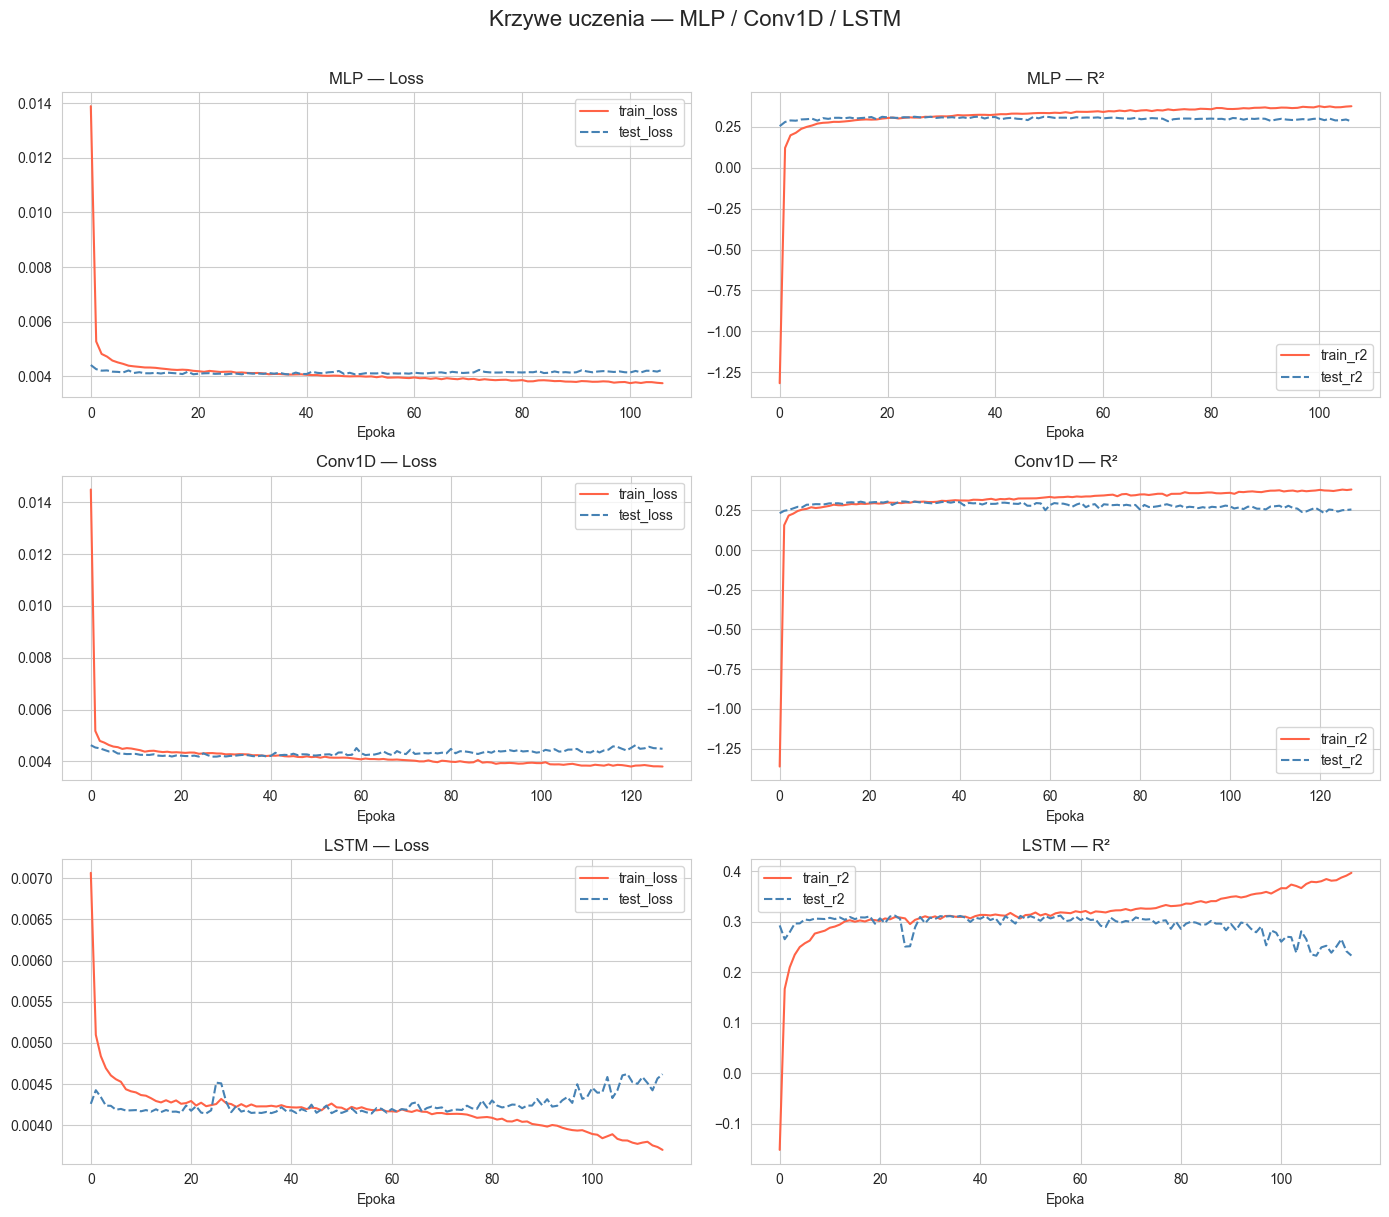

In [19]:
fig, axes = plt.subplots(len(MODEL_REGISTRY), 2, figsize=(14, 4 * len(MODEL_REGISTRY)))

for row, (name, res) in enumerate(ALL_RESULTS.items()):
    rf = pd.DataFrame(res)
    sns.lineplot(data=rf[["train_loss", "test_loss"]], ax=axes[row, 0],
                 palette=["tomato", "steelblue"])
    axes[row, 0].set_title(f"{name} — Loss")
    axes[row, 0].set_xlabel("Epoka")

    sns.lineplot(data=rf[["train_r2", "test_r2"]], ax=axes[row, 1],
                 palette=["tomato", "steelblue"])
    axes[row, 1].set_title(f"{name} — R²")
    axes[row, 1].set_xlabel("Epoka")

plt.suptitle("Krzywe uczenia — MLP / Conv1D / LSTM", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


In [20]:
TEST_DL_MAP = {
    "MLP":    test_dl_mlp,
    "Conv1D": test_dl_conv,
    "LSTM":   test_dl_lstm,
}

test_metrics = {}

for name, (model, _, _, _, _) in MODEL_REGISTRY.items():
    model.load_state_dict(ALL_BEST_STATES[name])
    model.eval()

    test_dl = TEST_DL_MAP[name]
    loss, mse, mae, r2, y_pred_t = trainer.test_step(test_dl, model, loss_fn
                                                     )

    test_metrics[name] = {
        "loss": loss, "MSE": mse, "MAE": mae, "R2": r2,
        "y_pred": y_pred_t
    }
    print(f"{name:8s} | Loss={loss:.4f}  MSE={mse:.4f}  MAE={mae:.4f}  R2={r2:.4f}")

print("\nPorównanie modeli na teście:")
pd.DataFrame(test_metrics).T[["loss", "MSE", "MAE", "R2"]].round(4)


IndexError: too many indices for tensor of dimension 2

In [ ]:
y_test_index = data_splits["y_test"].index

def build_preds_df(y_pred_tensor: torch.Tensor,
                   y_test_index,
                   scaler: StandardScaler,
                   data: pd.DataFrame,
                   model_name: str) -> pd.DataFrame:
    y_pred_inv = scaler.inverse_transform(y_pred_tensor.numpy())
    y_true_inv = scaler.inverse_transform(
        data_splits["y_test"].values
    )
    return pd.DataFrame({
        "model":   model_name,
        "name":    data.loc[y_test_index, "name"].values,
        "season":  data.loc[y_test_index, "season"].values,
        "gw":      data.loc[y_test_index, "gw"].values,
        "y_true":  y_true_inv.flatten(),
        "y_pred":  y_pred_inv.flatten(),
    })

preds_mlp = build_preds_df(
    test_metrics["MLP"]["y_pred"],
    y_test_index, target_scaler, data, "MLP"
)
preds_mlp.head(10)


In [ ]:
preds_mlp.y_pred.max(), preds_mlp.y_true.max()

In [ ]:
fig, ax = plt.subplots(ncols=2, figsize=(12, 5))

sns.histplot(data=preds_mlp, x="y_true", ax=ax[0], bins=30, color="steelblue", label="Rzeczywiste")
sns.histplot(data=preds_mlp, x="y_pred", ax=ax[0], bins=30, color="tomato", alpha=0.6, label="Predykcje MLP")
ax[0].set_title("Rozkład punktów — MLP")
ax[0].legend()

players = preds_mlp["name"].sample(1, random_state=777).values[0]
player_data = preds_mlp[preds_mlp["name"] == players].reset_index(drop=True)
sns.scatterplot(data=player_data, x=player_data.index, y="y_true",
                ax=ax[1], label="Rzeczywiste", color="steelblue")
sns.scatterplot(data=player_data, x=player_data.index, y="y_pred",
                ax=ax[1], label="MLP pred", color="tomato")
ax[1].set_title(f"Predykcje vs rzeczywiste — {players}")
plt.tight_layout()
plt.show()


In [ ]:
"""preds_mlp.to_parquet(config.PREDICTED_STATS_PATH)
print("Predykcje zapisane.")
"""